# Lab 3 (AST)

Whisper speech translation on Google FLEURS (en → uk).


In [41]:
# !pip install -q --no-deps \
#   "huggingface-hub==0.26.2" \
#   "tokenizers==0.20.3" \
#   "transformers==4.46.3" \
#   "datasets==3.1.0" \
#   "evaluate==0.4.3" \
#   "pytorch-lightning==2.4.0" \
#   "accelerate==1.0.1" \
#   "jiwer==3.0.5" \
#   "sacrebleu==2.4.3"

In [42]:
# !pip install -q sacrebleu==2.4.3

In [43]:
# !pip install -q --no-deps \
#   "unbabel-comet==2.2.4" \
#   "entmax==1.3"

In [44]:
import numpy as np
import pandas as pd
import torch

import huggingface_hub
import tokenizers
import transformers
import datasets
import evaluate
import pytorch_lightning as pl

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("torch:", torch.__version__)

print("huggingface_hub:", huggingface_hub.__version__)
print("tokenizers:", tokenizers.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("evaluate:", evaluate.__version__)
print("pl:", pl.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

numpy: 2.0.2
pandas: 2.3.3
torch: 2.10.0+cu128
huggingface_hub: 0.26.2
tokenizers: 0.20.3
transformers: 4.46.3
datasets: 3.1.0
evaluate: 0.4.3
pl: 2.4.0
cuda available: True
gpu: Tesla T4


In [45]:
import os
import gc
import math
import random
import re
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import pytorch_lightning as pl
import evaluate

from datasets import load_dataset, Audio
from torch.utils.data import Dataset, DataLoader
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    get_linear_schedule_with_warmup,
)
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import CSVLogger

In [46]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
pl.seed_everything(SEED, workers=True)
torch.set_float32_matmul_precision("medium")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

INFO:lightning_fabric.utilities.seed:Seed set to 42


device: cuda
gpu: Tesla T4


# 1. Config


In [47]:
CFG = {
    "model_name": "openai/whisper-small",
    "source_lang_cfg": "en_us",
    "target_lang_cfg": "uk_ua",
    "source_lang_name": "english",
    "target_lang_name": "ukrainian",
    "task": "translate",
    "sample_rate": 16000,
    "max_audio_seconds": 20.0,
    "train_batch_size": 2,
    "eval_batch_size": 2,
    "grad_accum": 8,
    "num_workers": 2,
    "learning_rate": 5e-6,
    "weight_decay": 1e-2,
    "warmup_ratio": 0.05,
    "max_epochs": 5,
    "freeze_encoder": True,
    "fp16": True,
    "max_new_tokens": 128,
    "limit_train_samples": None,
    "limit_val_samples": None,
    "limit_test_samples": None,
    "output_dir": "/kaggle/working/fleurs_ast_whisper" if os.path.exists("/kaggle") else "./fleurs_ast_whisper",
}
os.makedirs(CFG["output_dir"], exist_ok=True)
CFG

{'model_name': 'openai/whisper-small',
 'source_lang_cfg': 'en_us',
 'target_lang_cfg': 'uk_ua',
 'source_lang_name': 'english',
 'target_lang_name': 'ukrainian',
 'task': 'translate',
 'sample_rate': 16000,
 'max_audio_seconds': 20.0,
 'train_batch_size': 2,
 'eval_batch_size': 2,
 'grad_accum': 8,
 'num_workers': 2,
 'learning_rate': 5e-06,
 'weight_decay': 0.01,
 'warmup_ratio': 0.05,
 'max_epochs': 5,
 'freeze_encoder': True,
 'fp16': True,
 'max_new_tokens': 128,
 'limit_train_samples': None,
 'limit_val_samples': None,
 'limit_test_samples': None,
 'output_dir': '/kaggle/working/fleurs_ast_whisper'}

## 2. Helper functions


In [48]:
def normalize_text(text: str) -> str:
    text = str(text).strip()
    text = text.replace("’", "'").replace("`", "'").replace("ʼ", "'")
    text = re.sub(r"\s+", " ", text)
    return text

## 3. Dataset loading (FLEURS)


In [ ]:
from datasets import load_dataset

FLEURS_PARQUET_REV = "refs/pr/31"

en_train = load_dataset("google/fleurs", CFG["source_lang_cfg"], split="train", revision=FLEURS_PARQUET_REV)
en_val   = load_dataset("google/fleurs", CFG["source_lang_cfg"], split="validation", revision=FLEURS_PARQUET_REV)
en_test  = load_dataset("google/fleurs", CFG["source_lang_cfg"], split="test", revision=FLEURS_PARQUET_REV)

uk_train = load_dataset("google/fleurs", CFG["target_lang_cfg"], split="train", revision=FLEURS_PARQUET_REV)
uk_val   = load_dataset("google/fleurs", CFG["target_lang_cfg"], split="validation", revision=FLEURS_PARQUET_REV)
uk_test  = load_dataset("google/fleurs", CFG["target_lang_cfg"], split="test", revision=FLEURS_PARQUET_REV)

print(len(en_train), len(en_val), len(en_test))
print(len(uk_train), len(uk_val), len(uk_test))

2602 394 647
2810 325 750


In [ ]:
print(en_train.column_names)
print(en_train[0].keys())
print(en_train[0]["id"], uk_train[0]["id"])
print(en_train[0]["transcription"])
print(uk_train[0]["transcription"])

['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id']
dict_keys(['id', 'num_samples', 'path', 'audio', 'transcription', 'raw_transcription', 'gender', 'lang_id', 'language', 'lang_group_id'])
903 269
a tornado is a spinning column of very low-pressure air which sucks the surrounding air inward and upward
це перший випадок коли було висунуто обвинувачення відповідно до закону прийнятого у 2003 році з метою обмеження розсилки електронних листів користувачам тобто спама від небажаних відправників


In [51]:
en_train = en_train.cast_column("audio", Audio(sampling_rate=CFG["sample_rate"]))
en_val   = en_val.cast_column("audio", Audio(sampling_rate=CFG["sample_rate"]))
en_test  = en_test.cast_column("audio", Audio(sampling_rate=CFG["sample_rate"]))

## 4. Dataframe (parallel data)


In [52]:
def build_parallel_df(src_ds, tgt_ds, split_name: str):
    tgt_by_id = {}
    for ex in tgt_ds:
        tgt_by_id[ex["id"]] = normalize_text(ex["transcription"])

    rows = []
    for ex in src_ds:
        ex_id = ex["id"]
        if ex_id not in tgt_by_id:
            continue

        audio_arr = ex["audio"]["array"]
        sr = ex["audio"]["sampling_rate"]
        duration_sec = len(audio_arr) / sr

        if duration_sec > CFG["max_audio_seconds"]:
            continue

        rows.append(
            {
                "id": ex_id,
                "split": split_name,
                "audio": audio_arr,
                "sampling_rate": sr,
                "duration_sec": duration_sec,
                "source_text": normalize_text(ex["transcription"]),
                "target_text": tgt_by_id[ex_id],
            }
        )
    return pd.DataFrame(rows)

train_df = build_parallel_df(en_train, uk_train, "train")
val_df   = build_parallel_df(en_val, uk_val, "validation")
test_df  = build_parallel_df(en_test, uk_test, "test")

print("train:", len(train_df))
print("val:", len(val_df))
print("test:", len(test_df))

train: 2465
val: 357
test: 601


## 5. Split summary / sampling limits


In [53]:
if CFG["limit_train_samples"] is not None:
    train_df = train_df.iloc[:CFG["limit_train_samples"]].copy()
if CFG["limit_val_samples"] is not None:
    val_df = val_df.iloc[:CFG["limit_val_samples"]].copy()
if CFG["limit_test_samples"] is not None:
    test_df = test_df.iloc[:CFG["limit_test_samples"]].copy()

display(
    pd.DataFrame(
        {
            "split": ["train", "val", "test"],
            "samples": [len(train_df), len(val_df), len(test_df)],
            "hours": [
                train_df["duration_sec"].sum() / 3600,
                val_df["duration_sec"].sum() / 3600,
                test_df["duration_sec"].sum() / 3600,
            ],
        }
    )
)

train_df.head(3)

,split,samples,hours
0,train,2465,6.881967
1,val,357,0.923811
2,test,601,1.619850


,id,split,audio,sampling_rate,duration_sec,source_text,target_text
0,903,train,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",16000,6.80,a tornado is a spinning column of very low-pre...,торнадо це стовп повітря із дуже низьким тиско...
1,279,train,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",16000,7.68,former u.s. speaker of the house newt gingrich...,колишній спікер палати представників сша ньют ...
2,581,train,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",16000,17.28,these nerve impulses can be sent so quickly th...,ці нервові імпульси проходять тілом дуже швидк...


## 6. Whisper processor + model


In [54]:
processor = WhisperProcessor.from_pretrained(
    CFG["model_name"],
    language=CFG["target_lang_name"],
    task=CFG["task"],
)

model = WhisperForConditionalGeneration.from_pretrained(CFG["model_name"])

forced_decoder_ids = processor.get_decoder_prompt_ids(
    language=CFG["target_lang_name"],
    task=CFG["task"],
)

model.generation_config.forced_decoder_ids = forced_decoder_ids
model.generation_config.language = CFG["target_lang_name"]
model.generation_config.task = CFG["task"]

if CFG["freeze_encoder"]:
    model.model.encoder.requires_grad_(False)

print("Loaded:", CFG["model_name"])

Loaded: openai/whisper-small


## 7. Dataset and collator


In [55]:
class FleursASTDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, processor: WhisperProcessor):
        self.df = dataframe.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        audio = row["audio"]

        input_features = self.processor.feature_extractor(
            audio,
            sampling_rate=CFG["sample_rate"],
            return_tensors="pt",
        ).input_features[0]

        labels = self.processor.tokenizer(
            row["target_text"],
            return_tensors="pt",
            truncation=True,
        ).input_ids[0]

        return {
            "input_features": input_features,
            "labels": labels,
            "source_text": row["source_text"],
            "target_text": row["target_text"],
            "sample_id": row["id"],
        }

In [56]:
@dataclass
class WhisperCollator:
    processor: WhisperProcessor

    def __call__(self, features):
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        labels = labels_batch["input_ids"].masked_fill(labels_batch["attention_mask"].ne(1), -100)

        if labels.size(1) > 0 and (labels[:, 0] == self.processor.tokenizer.bos_token_id).all():
            labels = labels[:, 1:]

        batch["labels"] = labels
        batch["source_texts"] = [f["source_text"] for f in features]
        batch["target_texts"] = [f["target_text"] for f in features]
        batch["sample_ids"] = [f["sample_id"] for f in features]
        return batch

In [57]:
train_ds = FleursASTDataset(train_df, processor)
val_ds   = FleursASTDataset(val_df, processor)
test_ds  = FleursASTDataset(test_df, processor)

collator = WhisperCollator(processor)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["train_batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    pin_memory=torch.cuda.is_available(),
    collate_fn=collator,
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG["eval_batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=torch.cuda.is_available(),
    collate_fn=collator,
)

test_loader = DataLoader(
    test_ds,
    batch_size=CFG["eval_batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=torch.cuda.is_available(),
    collate_fn=collator,
)

batch = next(iter(train_loader))
{k: (v.shape if torch.is_tensor(v) else len(v)) for k, v in batch.items()}

{'input_features': torch.Size([2, 80, 3000]),
 'labels': torch.Size([2, 57]),
 'source_texts': 2,
 'target_texts': 2,
 'sample_ids': 2}

## 8. Metrics


In [58]:
bleu_metric = evaluate.load("bleu")
chrf_metric = evaluate.load("chrf")

def compute_text_metrics(pred_texts, ref_texts):
    pred_texts = [normalize_text(x) for x in pred_texts]
    ref_texts = [normalize_text(x) for x in ref_texts]

    bleu = bleu_metric.compute(
        predictions=pred_texts,
        references=[[x] for x in ref_texts],
    )["bleu"]

    chrf = chrf_metric.compute(
        predictions=pred_texts,
        references=[[x] for x in ref_texts],
    )["score"]

    return {
        "bleu": bleu,
        "chrf": chrf,
    }

## 9. Lightning module


In [59]:
class WhisperLightningModule(pl.LightningModule):
    def __init__(self, model, processor, train_steps: int, cfg: dict):
        super().__init__()
        self.model = model
        self.processor = processor
        self.train_steps = train_steps
        self.cfg = cfg
        self.save_hyperparameters(ignore=["model", "processor"])

    def training_step(self, batch, batch_idx):
        outputs = self.model(
            input_features=batch["input_features"],
            labels=batch["labels"],
        )
        loss = outputs.loss
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, batch_size=batch["input_features"].size(0))
        return loss

    @torch.no_grad()
    def shared_eval_step(self, batch, stage="val"):
        outputs = self.model(
            input_features=batch["input_features"],
            labels=batch["labels"],
        )
        loss = outputs.loss

        generated_ids = self.model.generate(
            input_features=batch["input_features"],
            max_new_tokens=CFG["max_new_tokens"],
            num_beams=1,
        )

        label_ids = batch["labels"].clone()
        label_ids[label_ids == -100] = self.processor.tokenizer.pad_token_id

        pred_texts = self.processor.batch_decode(generated_ids, skip_special_tokens=True)
        ref_texts = self.processor.batch_decode(label_ids, skip_special_tokens=True)

        metrics = compute_text_metrics(pred_texts, ref_texts)

        self.log(f"{stage}_loss", loss, prog_bar=True, on_epoch=True, batch_size=batch["input_features"].size(0))
        self.log(f"{stage}_bleu", metrics["bleu"], prog_bar=True, on_epoch=True, batch_size=batch["input_features"].size(0))
        self.log(f"{stage}_chrf", metrics["chrf"], prog_bar=True, on_epoch=True, batch_size=batch["input_features"].size(0))

        return loss

    def validation_step(self, batch, batch_idx):
        return self.shared_eval_step(batch, "val")

    def test_step(self, batch, batch_idx):
        return self.shared_eval_step(batch, "test")

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.cfg["learning_rate"],
            weight_decay=self.cfg["weight_decay"],
        )

        warmup_steps = int(self.train_steps * self.cfg["warmup_ratio"])
        scheduler = get_linear_schedule_with_warmup(
            optimizer=optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=self.train_steps,
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step",
                "frequency": 1,
            },
        }

## 10. Trainer


In [60]:
steps_per_epoch = max(1, math.ceil(len(train_loader) / CFG["grad_accum"]))
train_steps = steps_per_epoch * CFG["max_epochs"]

lit_model = WhisperLightningModule(model, processor, train_steps=train_steps, cfg=CFG)

checkpoint_cb = ModelCheckpoint(
    dirpath=os.path.join(CFG["output_dir"], "checkpoints"),
    filename="whisper-ast-{epoch:02d}-{val_chrf:.3f}",
    monitor="val_chrf",
    mode="max",
    save_top_k=1,
    save_last=True,
)

early_stop_cb = EarlyStopping(monitor="val_chrf", mode="max", patience=2)
lr_monitor = LearningRateMonitor(logging_interval="step")
logger = CSVLogger(save_dir=CFG["output_dir"], name="logs")

trainer = pl.Trainer(
    default_root_dir=CFG["output_dir"],
    max_epochs=CFG["max_epochs"],
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    precision="16-mixed" if torch.cuda.is_available() and CFG["fp16"] else 32,
    accumulate_grad_batches=CFG["grad_accum"],
    gradient_clip_val=1.0,
    logger=logger,
    callbacks=[checkpoint_cb, early_stop_cb, lr_monitor],
    log_every_n_steps=5,
)

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


## 11. Training


In [61]:
trainer.fit(lit_model, train_loader, val_loader)

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /kaggle/working/fleurs_ast_whisper/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type                            | Params | Mode
-----------------------------------------------------------------
0 | model | WhisperForConditionalGeneration | 241 M  | eval
-----------------------------------------------------------------
153 M     Trainable params
88.2 M    Non-trainable params
241 M     Total params
966.940   Total estimated model params size (MB)
0         Modules in train mode
350       Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


## 12. Best checkpoint


In [62]:
best_ckpt = checkpoint_cb.best_model_path
print("best checkpoint:", best_ckpt)

best_model = WhisperLightningModule.load_from_checkpoint(
    best_ckpt,
    model=WhisperForConditionalGeneration.from_pretrained(CFG["model_name"]),
    processor=processor,
    train_steps=train_steps,
    cfg=CFG,
)

best_model.model.generation_config.forced_decoder_ids = forced_decoder_ids
best_model.model.generation_config.language = CFG["target_lang_name"]
best_model.model.generation_config.task = CFG["task"]
best_model.eval().to(device)

best checkpoint: /kaggle/working/fleurs_ast_whisper/checkpoints/whisper-ast-epoch=04-val_chrf=26.188.ckpt


WhisperLightningModule(
  (model): WhisperForConditionalGeneration(
    (model): WhisperModel(
      (encoder): WhisperEncoder(
        (conv1): Conv1d(80, 768, kernel_size=(3,), stride=(1,), padding=(1,))
        (conv2): Conv1d(768, 768, kernel_size=(3,), stride=(2,), padding=(1,))
        (embed_positions): Embedding(1500, 768)
        (layers): ModuleList(
          (0-11): 12 x WhisperEncoderLayer(
            (self_attn): WhisperSdpaAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=False)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            

## 13. Inference on test set


In [63]:
@torch.no_grad()
def predict_dataset(model_module, dataloader, processor, device="cpu"):
    model_module.eval().to(device)
    rows = []

    for batch in dataloader:
        input_features = batch["input_features"].to(device, non_blocking=True)

        generated_ids = model_module.model.generate(
            input_features=input_features,
            max_new_tokens=CFG["max_new_tokens"],
            num_beams=1,
        )

        pred_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)

        label_ids = batch["labels"].clone()
        label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
        ref_texts = processor.batch_decode(label_ids, skip_special_tokens=True)

        rows.extend(
            {
                "sample_id": sample_id,
                "source_text": source_text,
                "reference": normalize_text(ref),
                "prediction": normalize_text(pred),
            }
            for sample_id, source_text, pred, ref in zip(
                batch["sample_ids"],
                batch["source_texts"],
                pred_texts,
                ref_texts,
            )
        )

    result_df = pd.DataFrame(rows)
    text_metrics = compute_text_metrics(
        result_df["prediction"].tolist(),
        result_df["reference"].tolist(),
    )
    return result_df, text_metrics

In [64]:
pred_df, text_metrics = predict_dataset(best_model, test_loader, processor, device=device)
print(text_metrics)
pred_df.head(20)

{'bleu': 0.019871252064811853, 'chrf': 26.11306539786134}


,sample_id,source_text,reference,prediction
0,1904,however due to the slow communication channels...,однак через повільні канали комунікації західн...,проте через розмію комінційних каналів стиль у...
1,1728,the cabbage juice changes color depending on h...,сік капусти змінює колір у залежності від того...,кабус-друс змінюється виглядно як істотний осн...
2,1972,many people don't think about them as dinosaur...,багато людей не думають про них як про динозав...,багато людей не думають про них як кіночки том...
3,1938,the hospital has followed protocol for infecti...,лікарня дотримувалася протоколу інфекційного к...,посібний співпроводний протокол включає виріши...
4,1876,the northern marianas emergency management off...,управління надзвичайними ситуаціями північних ...,навець марианна національній обмеження вирішен...
5,1914,twentieth century research has shown that ther...,проведене у двадцятому столітті дослідження по...,після 20-го століття розповсюджують що є два п...
6,1846,the aspect ratio of this format dividing by tw...,співвідношення сторін цього формату поділене н...,справді цього форматура висновлення з 12 до ви...
7,1806,as light pollution in their heyday was not the...,оскільки світлове забруднення в період їхнього...,якщо літополісні в їхній день не є такими проб...
8,1729,for example each year students from bennet sch...,наприклад студенти школи беннета в північній к...,у кожну зію що студенти з бенетського школи в ...
9,1919,the city is also the base to climb the nyirago...,це місто також слугує базою для підйому на вул...,ця місця також є базою щоб виступати на найрай...


## 14. COMET evaluation


In [65]:
from comet import download_model, load_from_checkpoint

comet_model_path = download_model("Unbabel/wmt22-comet-da")
comet_model = load_from_checkpoint(comet_model_path)

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.4.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../root/.cache/huggingface/hub/models--Unbabel--wmt22-comet-da/snapshots/2760a223ac957f30acfb18c8aa649b01cf1d75f2/checkpoints/model.ckpt`
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']


In [66]:
comet_model.encoder.model.config.output_hidden_states = True

if hasattr(comet_model.encoder.model.config, "return_dict"):
    comet_model.encoder.model.config.return_dict = False

In [67]:
comet_data = [
    {
        "src": row["source_text"],
        "mt": row["prediction"],
        "ref": row["reference"],
    }
    for _, row in pred_df.iterrows()
]

comet_output = comet_model.predict(
    comet_data,
    batch_size=8,
    gpus=1 if torch.cuda.is_available() else 0,
)

print("COMET:", comet_output.system_score)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Predicting DataLoader 0: 100%|██████████| 76/76 [00:20<00:00,  3.66it/s]


COMET: 0.41011895923666075


## 15. Summary and saving


In [68]:
summary = pd.DataFrame(
    [
        {
            "model_name": CFG["model_name"],
            "dataset": "google/fleurs",
            "source_lang": CFG["source_lang_cfg"],
            "target_lang": CFG["target_lang_cfg"],
            "task": CFG["task"],
            "train_samples": len(train_df),
            "val_samples": len(val_df),
            "test_samples": len(test_df),
            "BLEU": text_metrics["bleu"],
            "chrF": text_metrics["chrf"],
            "COMET": comet_output.system_score,
        }
    ]
)
summary

,model_name,dataset,source_lang,target_lang,task,train_samples,val_samples,test_samples,BLEU,chrF,COMET
0,openai/whisper-small,google/fleurs,en_us,uk_ua,translate,2465,357,601,0.019871,26.113065,0.410119


In [69]:
pred_path = os.path.join(CFG["output_dir"], "fleurs_ast_predictions.csv")
summary_path = os.path.join(CFG["output_dir"], "fleurs_ast_summary.csv")

pred_df.to_csv(pred_path, index=False, encoding="utf-8")
summary.to_csv(summary_path, index=False, encoding="utf-8")

print("saved:", pred_path)
print("saved:", summary_path)

saved: /kaggle/working/fleurs_ast_whisper/fleurs_ast_predictions.csv
saved: /kaggle/working/fleurs_ast_whisper/fleurs_ast_summary.csv


In [70]:
save_dir = os.path.join(CFG["output_dir"], "best_hf_model")
os.makedirs(save_dir, exist_ok=True)

best_model.model.save_pretrained(save_dir)
processor.save_pretrained(save_dir)

print("saved model to:", save_dir)

/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:2817: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 448, 'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27, 28, 29, 31, 58, 59, 60, 61, 62, 63, 90, 91, 92, 93, 359, 503, 522, 542, 873, 893, 902, 918, 922, 931, 1350, 1853, 1982, 2460, 2627, 3246, 3253, 3268, 3536, 3846, 3961, 4183, 4667, 6585, 6647, 7273, 9061, 9383, 10428, 10929, 11938, 12033, 12331, 12562, 13793, 14157, 14635, 15265, 15618, 16553, 16604, 18362, 18956, 20075, 21675, 22520, 26130, 26161, 26435, 28279, 29464, 31650, 32302, 32470, 36865, 42863, 47425, 49870, 50254, 50258, 50360, 50361, 50362], 'begin_suppress_tokens': [220, 50257]}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


saved model to: /kaggle/working/fleurs_ast_whisper/best_hf_model


BLEU: 0.0199
chrF: 26.11


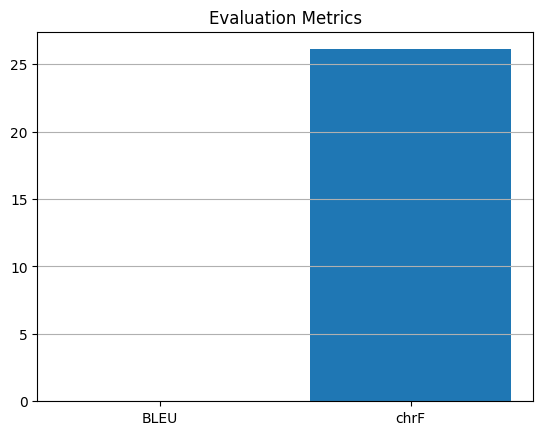

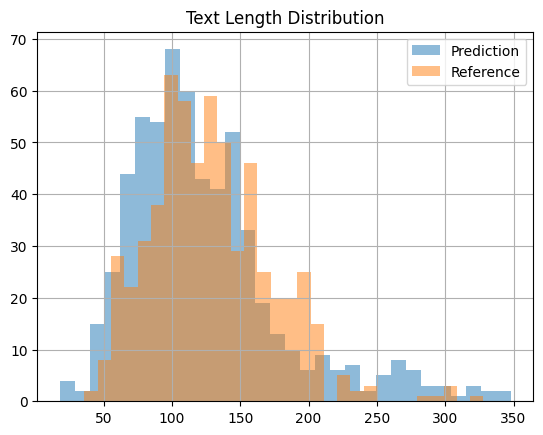

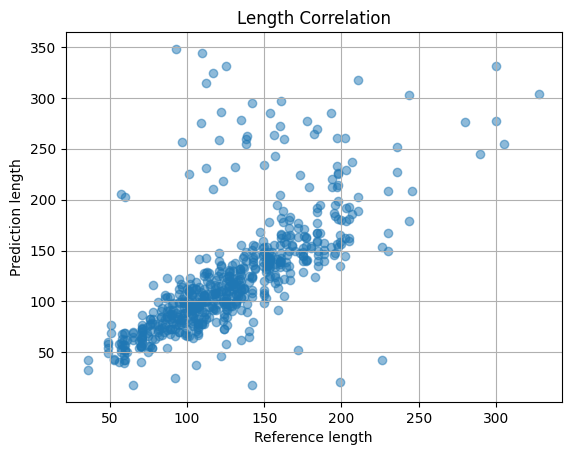


===== SAMPLE TRANSLATIONS =====

REFERENCE:
зокрема стверджують що можливо визначити чи бреше людина за допомогою правильної інтерпретації мікровиразів

PREDICTION:
у частину це заявлено що один можна детекти що їхня людина має вибори вимоги майкору використану


REFERENCE:
атомна бомба працює за таким принципом що вона бере енергію щоб зібрати разом ядро з багатьома протонами та нейтронами

PREDICTION:
фізичний бом був на принципі того що виглядає енергії щоб збираючися на кукульту з багатим протоном та нейтроном


REFERENCE:
ви також можете захотіти проконсультуватися з урядами інших країн окрім вашої але їхні поради розроблені для їхніх громадян

PREDICTION:
можливо ви також хочете послугувати влади іншими своїми але своє послугу є зробити для своїх жителів


REFERENCE:
усі живуть у суспільстві і користуються транспортними системами при цьому мало не всі скаржаться на них

PREDICTION:
все вирішують в соціальному і використовують транспортні системи майже всі варіють про транспортні

In [71]:
import matplotlib.pyplot as plt
import sacrebleu
import evaluate
import random

preds = pred_df["prediction"].tolist()
refs = pred_df["reference"].tolist()

bleu = evaluate.load("bleu").compute(
    predictions=preds,
    references=[[r] for r in refs]
)["bleu"]

chrf = sacrebleu.corpus_chrf(preds, [refs]).score

print(f"BLEU: {bleu:.4f}")
print(f"chrF: {chrf:.2f}")

plt.figure()
plt.bar(["BLEU", "chrF"], [bleu, chrf])
plt.title("Evaluation Metrics")
plt.grid(axis="y")
plt.show()

pred_lengths = pred_df["prediction"].str.len()
ref_lengths = pred_df["reference"].str.len()

plt.figure()
plt.hist(pred_lengths, bins=30, alpha=0.5, label="Prediction")
plt.hist(ref_lengths, bins=30, alpha=0.5, label="Reference")
plt.title("Text Length Distribution")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.scatter(ref_lengths, pred_lengths, alpha=0.5)
plt.xlabel("Reference length")
plt.ylabel("Prediction length")
plt.title("Length Correlation")
plt.grid()
plt.show()

print("\n===== SAMPLE TRANSLATIONS =====\n")

samples = pred_df.sample(5)

for _, row in samples.iterrows():
    print("REFERENCE:")
    print(row["reference"])
    print("\nPREDICTION:")
    print(row["prediction"])
    print("\n" + "="*60 + "\n")